# Confronto Sistematico tra Algoritmi di Deep Reinforcement Learning


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Stile grafico per visualizzazioni accademiche chiare
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["axes.edgecolor"] = "#BDC3C7"
plt.rcParams["axes.linewidth"] = 0.8

## 1. Risultati su CartPole-v1

Il confronto usa le valutazioni deterministiche finali dei migliori checkpoint. La deviazione standard misura la dispersione delle medie ottenute dai cinque seed; minimo e massimo descrivono invece gli estremi osservati negli episodi finali. I valori vanno quindi interpretati insieme, senza confondere la variabilita' tra seed con quella interna a ciascuna valutazione.

,Algoritmo,Famiglia,Reward Medio,Dev. Std.,Minimo,Massimo
0,REINFORCE Standard,Policy Gradient (MC),498.6,3.1,430.0,500.0
1,REINFORCE + Value Baseline,Policy Gradient + Baseline,499.9,0.1,497.0,500.0
2,Advantage Actor-Critic (A2C),Actor-Critic (TD n-step),402.2,156.0,135.0,500.0
3,Deep Q-Learning (DQN),Value-Based (Off-Policy),494.6,12.0,459.0,500.0


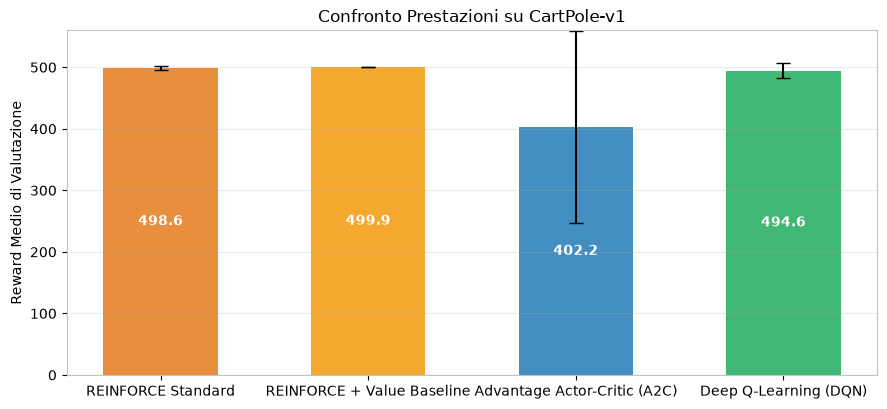

In [2]:
cartpole_data = [
    {
        "Algoritmo": "REINFORCE Standard",
        "Famiglia": "Policy Gradient (MC)",
        "Reward Medio": 498.6,
        "Dev. Std.": 3.1,
        "Minimo": 430.0,
        "Massimo": 500.0
    },
    {
        "Algoritmo": "REINFORCE + Value Baseline",
        "Famiglia": "Policy Gradient + Baseline",
        "Reward Medio": 499.9,
        "Dev. Std.": 0.1,
        "Minimo": 497.0,
        "Massimo": 500.0
    },
    {
        "Algoritmo": "Advantage Actor-Critic (A2C)",
        "Famiglia": "Actor-Critic (TD n-step)",
        "Reward Medio": 402.2,
        "Dev. Std.": 156.0,
        "Minimo": 135.0,
        "Massimo": 500.0
    },
    {
        "Algoritmo": "Deep Q-Learning (DQN)",
        "Famiglia": "Value-Based (Off-Policy)",
        "Reward Medio": 494.6,
        "Dev. Std.": 12.0,
        "Minimo": 459.0,
        "Massimo": 500.0
    }
]

df_cartpole = pd.DataFrame(cartpole_data)
display(df_cartpole)

# Grafico comparativo CartPole
fig, ax = plt.subplots(figsize=(9, 4.2))
colors = ["#E67E22", "#F39C12", "#2980B9", "#27AE60"]
bars = ax.bar(df_cartpole["Algoritmo"], df_cartpole["Reward Medio"], yerr=df_cartpole["Dev. Std."], capsize=5, color=colors, alpha=0.88, width=0.55)
ax.set_ylabel("Reward Medio di Valutazione")
ax.set_title("Confronto Prestazioni su CartPole-v1")
ax.set_ylim(0, 560)
ax.grid(axis="y", alpha=0.25)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{height:.1f}", xy=(bar.get_x() + bar.get_width() / 2, height / 2), xytext=(0, 0), textcoords="offset points", ha="center", va="center", color="white", fontweight="bold")

plt.tight_layout()
plt.show()

## 2. Risultati su LunarLander-v3

Su LunarLander il confronto riguarda tre seed per algoritmo. A2C mostra episodi occasionalmente positivi ma una media ancora negativa; DQN supera invece la soglia di reward 200 in tutte le valutazioni medie per seed. Il risultato descrive queste configurazioni e questi budget sperimentali, non una superiorita' universale dei metodi off-policy.

,Algoritmo,Configurazione,Reward Medio Valutazione,Minimo Osservato,Massimo Osservato
0,Advantage Actor-Critic (A2C),"SyncVectorEnv (8 envs, n-step=5)",-70.4,-238.3,185.7
1,Deep Q-Learning (DQN),ReplayBuffer (150k) + TargetNet (1000 step),274.0,140.0,314.4


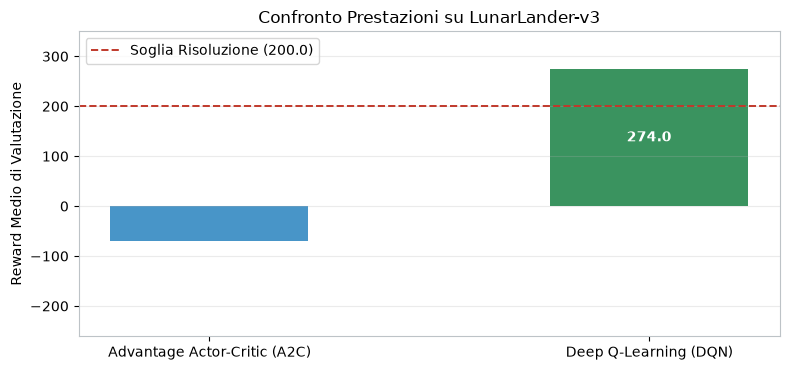

In [3]:
lunarlander_data = [
    {
        "Algoritmo": "Advantage Actor-Critic (A2C)",
        "Configurazione": "SyncVectorEnv (8 envs, n-step=5)",
        "Reward Medio Valutazione": -70.4,
        "Minimo Osservato": -238.3,
        "Massimo Osservato": 185.7
    },
    {
        "Algoritmo": "Deep Q-Learning (DQN)",
        "Configurazione": "ReplayBuffer (150k) + TargetNet (1000 step)",
        "Reward Medio Valutazione": 274.0,
        "Minimo Osservato": 140.0,
        "Massimo Osservato": 314.4
    }
]

df_lunar = pd.DataFrame(lunarlander_data)
display(df_lunar)

# Grafico comparativo LunarLander
fig, ax = plt.subplots(figsize=(8, 3.8))
colors_lunar = ["#2E86C1", "#1E8449"]
bars_lunar = ax.bar(df_lunar["Algoritmo"], df_lunar["Reward Medio Valutazione"], color=colors_lunar, alpha=0.88, width=0.45)
ax.axhline(200.0, color="#C0392B", linestyle="--", linewidth=1.4, label="Soglia Risoluzione (200.0)")
ax.set_ylabel("Reward Medio di Valutazione")
ax.set_title("Confronto Prestazioni su LunarLander-v3")
ax.set_ylim(-260, 350)
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="upper left")

for bar in bars_lunar:
    height = bar.get_height()
    ax.annotate(f"{height:.1f}", xy=(bar.get_x() + bar.get_width() / 2, max(height / 2, 20)), xytext=(0, 0), textcoords="offset points", ha="center", va="center", color="white", fontweight="bold")

plt.tight_layout()
plt.show()